In [96]:
import os
import time
import glob
import pandas as pd
import numpy as np
import xarray as xr
import dask.dataframe as dd
from scipy.ndimage import gaussian_filter
from joblib import Parallel, delayed, cpu_count
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import datetime as dt
import warnings

warnings.filterwarnings("ignore")

# --- CONFIGURATION ---
START_DATE = dt.datetime(2019, 8, 1)
END_DATE = dt.datetime(2019, 10, 31)
LAT_RANGE = (-40, 20)
LON_RANGE = (-75, -65)
TARGET_UT = 21

# Paths (Adjust these to your local structure)
BASE_DIR = "/Users/prasoonv/hpc_project_final/project_1/"
MADRIGAL_DIR = f"{BASE_DIR}data/raw/madrigal_data/"
LISN_DIR = f"{BASE_DIR}data/raw/lisn_data/"
WACCMX_FILE = f"{BASE_DIR}data/raw/waccmx_data/waccmx_tec_1.nc"
ERA5_U_FILE = f"{BASE_DIR}data/raw/era5_data/u60_Antarctic_SSW.csv"
ERA5_T_FILE = f"{BASE_DIR}data/raw/era5_data/tpolar_Antarctic_SSW.csv"

In [97]:
# ==========================================
# 1. I/O BENCHMARKING (DASK VS PANDAS)
# ==========================================
def benchmark_io():
    """Benchmarks reading and basic time-filtering of Madrigal CSVs."""
    print("--- Running I/O Benchmark (Pandas vs Dask) ---")
    files = glob.glob(os.path.join(MADRIGAL_DIR, "*.txt")) #[:10] # Subset for test
    print(f"Found {len(files)} files for I/O benchmark.")

    # Serial Pandas
    t0 = time.time()
    dfs = []
    for f in files:
        df = pd.read_csv(f, sep=r'\s+', usecols=['YEAR','MONTH','DAY','HOUR','MIN','GDLAT','GLON','TEC'])
        # Filter UT ~21H (+/- 30 min approx)
        df = df[(df['HOUR'] == TARGET_UT) | ((df['HOUR'] == TARGET_UT - 1) & (df['MIN'] >= 30))]
        dfs.append(df)
        
    pd_df = pd.concat(dfs)
    serial_io_time = time.time() - t0
    print(f"Pandas Serial I/O: {serial_io_time:.2f}s")

    # Parallel Dask
    t0 = time.time()
    ddf = dd.read_csv(files, sep=r'\s+', usecols=['YEAR','MONTH','DAY','HOUR','MIN','GDLAT','GLON','TEC'])
    ddf = ddf[(ddf.HOUR == TARGET_UT) | ((ddf.HOUR == TARGET_UT - 1) & (ddf.MIN >= 30))]
    dask_df = ddf.compute() # Materialize
    dask_io_time = time.time() - t0
    print(f"Dask Parallel I/O: {dask_io_time:.2f}s")
    print(f"I/O Speedup: {serial_io_time / dask_io_time:.2f}x\n")
    
    return dask_df

# ==========================================
# 2. COMPUTE BENCHMARKING (SPATIAL & GAUSSIAN)
# ==========================================
def process_single_day(date, df_subset):
    """CPU-bound task: 2D Histogram binning and Gaussian smoothing for a single day."""
    if df_subset.empty:
        return date, np.full((60,), np.nan) # Assuming 1-degree lat bins
        
    lons = df_subset["GLON"].to_numpy()
    lats = df_subset["GDLAT"].to_numpy()
    vtec_vals = df_subset["TEC"].to_numpy()

    # Grid parameters
    lon_edges = np.linspace(-75, -65, 11) # 1-degree resolution
    lat_edges = np.linspace(-40, 20, 61)  # 1-degree resolution

    sum_vtec, _, _ = np.histogram2d(lats, lons, bins=[lat_edges, lon_edges], weights=vtec_vals)
    count, _, _ = np.histogram2d(lats, lons, bins=[lat_edges, lon_edges])

    mean_vtec = np.divide(sum_vtec, count, out=np.full_like(sum_vtec, np.nan), where=count > 0)

    # Gaussian Smoothing (NaN safe)
    valid_mask = ~np.isnan(mean_vtec)
    filled = np.where(valid_mask, mean_vtec, 0)
    
    smooth = gaussian_filter(filled, sigma=1.2)
    weights = gaussian_filter(valid_mask.astype(float), sigma=1.2)
    
    mean_vtec_smooth = np.divide(smooth, weights, out=np.full_like(smooth, np.nan), where=weights > 0)

    # Average across the longitude band (axis 1) to get a 1D array of Latitude vs VTEC for this day
    zonal_mean = np.nanmean(mean_vtec_smooth, axis=1)
    return date, zonal_mean


# ==========================================
# 2. DASK LOADING & FILTERING FOR LISN
# ==========================================
def load_lisn_with_dask(base_dir, lat_range, lon_range, target_ut):
    """
    Lazily loads LISN Parquet files across all subfolders, applies spatial/temporal 
    filtering, and materializes the result into a Pandas DataFrame.
    """
    print("--- Loading LISN Parquet Data with Dask ---")
    t0 = time.time()
    
    # Dask handles the globbing across all dayXXX-XXX subfolders automatically
    file_pattern = os.path.join(base_dir, "data/raw/lisn_data/*/*.parquet")
    
    # Read binary files using PyArrow engine
    ddf = dd.read_parquet(file_pattern, engine='pyarrow')
    
    # Rename columns so it works seamlessly with benchmark_compute()
    ddf = ddf.rename(columns={
        'ipp_lat': 'GDLAT',
        'ipp_lon': 'GLON',
        'vtec': 'TEC',
        'date': 'DT'
    })
    
    # 1. Spatial Filter (Pushing this to Dask before compute() saves massive memory)
    ddf = ddf[
        (ddf['GDLAT'] >= lat_range[0]) & (ddf['GDLAT'] <= lat_range[1]) &
        (ddf['GLON'] >= lon_range[0]) & (ddf['GLON'] <= lon_range[1])
    ]
    
    # 2. Temporal Filter (~21 UT +/- 30 mins)
    ddf = ddf[
        (ddf['DT'].dt.hour == target_ut) | 
        ((ddf['DT'].dt.hour == target_ut - 1) & (ddf['DT'].dt.minute >= 30))
    ]
    
    # Materialize the distributed graph into a single Pandas DataFrame
    df = ddf.compute()
    
    load_time = time.time() - t0
    print(f"LISN Dask Load & Filter Time: {load_time:.2f}s")
    print(f"Total LISN rows retained for compute: {len(df)}\n")
    
    return df

import dask.dataframe as dd

def load_lisn_with_dask(parquet_dir, lat_range, lon_range, target_ut):
    """
    Lazily loads LISN Parquet files, applies spatial/temporal 
    filtering, and materializes the result into a Pandas DataFrame.
    """
    print("--- Loading Actual LISN Parquet Data with Dask ---")
    t0 = time.time()
    
    # Read all binary parquet files directly from the outputs folder
    file_pattern = os.path.join(parquet_dir, "day*/*.parquet")
    ddf = dd.read_parquet(file_pattern, engine='pyarrow')
    
    #print(ddf.head())  # Debug: Check initial columns and data types
    
    # Rename columns so it works seamlessly with benchmark_compute()
    ddf = ddf.rename(columns={
        'ipp_lat': 'GDLAT',
        'ipp_lon': 'GLON',
        'vtec': 'TEC',
        'date': 'DT'
    })
    
    # 1. Spatial Filter (Pushing this to Dask before compute() saves massive memory)
    ddf = ddf[
        (ddf['GDLAT'] >= lat_range[0]) & (ddf['GDLAT'] <= lat_range[1]) &
        (ddf['GLON'] >= lon_range[0]) & (ddf['GLON'] <= lon_range[1])
    ]
    
    # 2. Temporal Filter (~21 UT +/- 30 mins)
    ddf = ddf[
        (ddf['DT'].dt.hour == target_ut) | 
        ((ddf['DT'].dt.hour == target_ut - 1) & (ddf['DT'].dt.minute >= 30))
    ]
    
    # Materialize the distributed graph into a single Pandas DataFrame
    df = ddf.compute()
    
    load_time = time.time() - t0
    print(f"LISN Dask Load & Filter Time: {load_time:.2f}s")
    print(f"Total LISN rows retained for compute: {len(df)}\n")
    
    return df


def benchmark_compute(df, dataset_name="Dataset"):
    """Benchmarks serial vs process-parallel vs thread-parallel execution."""
    print(f"--- Running Compute Benchmark for {dataset_name} ---")
    
    # 1. Standardize the Date column
    if 'DT' not in df.columns:
        df['DT'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']])
    else:
        df['DT'] = pd.to_datetime(df['DT'])
        
    df['Date_Only'] = df['DT'].dt.floor('D')
    grouped = [group for name, group in df.groupby('Date_Only')]
    
    print(f"Total days to process: {len(grouped)} | Total rows: {len(df)}")
    
    # ---------------------------------------------------------
    # TEST 1: SERIAL BASELINE
    # ---------------------------------------------------------
    t0 = time.time()
    serial_res = [process_single_day(group['Date_Only'].iloc[0], group) for group in grouped]
    serial_time = time.time() - t0
    print(f"1. Serial Loop: {serial_time:.2f}s")

    # ---------------------------------------------------------
    # TEST 2: MULTIPROCESSING (Distributed Memory - High Overhead)
    # ---------------------------------------------------------
    t0 = time.time()
    slurm_cpus = 6 #int(os.environ.get('SLURM_CPUS_PER_TASK', (os.cpu_count() - 2) or 1))
    
    _ = Parallel(n_jobs=slurm_cpus)(
        delayed(process_single_day)(group['Date_Only'].iloc[0], group) for group in grouped
    )
    process_time = time.time() - t0
    print(f"2. Joblib Processes ({slurm_cpus} cores): {process_time:.2f}s (Speedup: {serial_time/process_time:.2f}x)")

    # ---------------------------------------------------------
    # TEST 3: MULTITHREADING (Shared Memory - Low Overhead)
    # ---------------------------------------------------------
    t0 = time.time()
    
    thread_res = Parallel(n_jobs=slurm_cpus, prefer="threads")(
        delayed(process_single_day)(group['Date_Only'].iloc[0], group) for group in grouped
    )
    thread_time = time.time() - t0
    print(f"3. Joblib Threads ({slurm_cpus} threads): {thread_time:.2f}s (Speedup: {serial_time/thread_time:.2f}x)\n")
    
    # Restructure into Time x Lat array using the fastest result
    thread_res.sort(key=lambda x: x[0]) 
    dates = [x[0] for x in thread_res]
    vtec_matrix = np.vstack([x[1] for x in thread_res])
    
    return dates, vtec_matrix

# ==========================================
# 3. PLOTTING PIPELINE
# ==========================================
def plot_all_rows(waccmx_ds, era5_u, era5_t, madrigal_data, lisn_data, date_range):
    
    start_date, end_date = date_range
    
    """
    Constructs the 5-row stacked plot.
    madrigal_data and lisn_data should be tuples of (dates, 2D_vtec_matrix).
    """
    fig = plt.figure(figsize=(14, 30))
    gs = gridspec.GridSpec(
        5, 2, 
        width_ratios=[20, 1], 
        height_ratios=[1,1,1,1,1], 
        hspace=0.2, wspace=0.05
    )

    # Time axes setup
    time_waccmx = waccmx_ds["Time"].values
    
    # ROW 1: WACCM-X Kp and F10.7
    ax1 = fig.add_subplot(gs[0,0])
    ax1.plot(time_waccmx, waccmx_ds.kp, color='black', linewidth=2)
    ax1.set_ylabel("Kp", fontsize=18)
    ax1.set_ylim(0, 6)
    ax1.axhline(4, color='black', linestyle='--', linewidth=1.2)
    ax1.tick_params(axis='both', labelsize=16)
    ax1.set_xlim(start_date, end_date)
    ax1.xaxis.set_major_locator(mdates.DayLocator(interval=6))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax1.grid()

    ax1_t = ax1.twinx()
    ax1_t.plot(time_waccmx, waccmx_ds.f107, color='red', linewidth=2)
    ax1_t.set_ylabel("F10.7 (sfu)", color='red', fontsize=18)
    ax1_t.tick_params(axis='y', labelcolor='red', labelsize=16)
    ax1.set_title("Kp and F10.7 Values Over Time", fontsize=20)

    # ROW 2: ERA5 Stratosphere
    ax2 = fig.add_subplot(gs[1,0])
    ax2.plot(era5_u["time"], era5_u["u60"], color='blue', linewidth=2)
    ax2.set_ylabel("Un (m/s), 60N 10hPa", fontsize=18)
    ax2.grid(True)
    ax2.axhline(0, color='black', linestyle='--', linewidth=1.2)
    ax2.set_xlim(start_date, end_date)
    ax2.xaxis.set_major_locator(mdates.DayLocator(interval=6))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax2.tick_params(axis='both', labelsize=16)

    ax2_t = ax2.twinx()
    ax2_t.plot(era5_t["time"], era5_t["t90"], color='red', linewidth=2)
    ax2_t.set_ylabel("Mean Temp (K), 60–90N", color='red', fontsize=18)
    ax2_t.tick_params(axis='y', labelcolor='red', labelsize=16)
    ax2.set_title("Stratospheric Zonal Winds & Temperature", fontsize=20)

    # HELPER FOR CONTOUR PLOTS (Rows 3, 4, 5)
    def plot_tec_contour(ax_idx, data_matrix, dates, lats, title):
        ax = fig.add_subplot(gs[ax_idx, 0])
        cax = fig.add_subplot(gs[ax_idx, 1])
        
        # Convert dates to numerical format for contourf
        T, LAT = np.meshgrid(mdates.date2num(dates), lats)
        
        cf = ax.contourf(T, LAT, data_matrix.T, levels=np.arange(0, 30, 2), cmap='jet', extend='max')
        cbar = fig.colorbar(cf, cax=cax)
        cbar.set_label("VTEC (TECU)", fontsize=16)
        cbar.ax.tick_params(labelsize=14)
        
        ax.set_title(title, fontsize=20)
        ax.set_ylabel("Latitude", fontsize=18)
        ax.set_xlim(start_date, end_date)
        ax.set_ylim(-40, 20)
        ax.grid(True)
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=6))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax.tick_params(axis='both', labelsize=16)
        ax.axhline(-11, color='black', linestyle='--', linewidth=1.2)
        ax.axvline(mdates.date2num(dt.datetime(2019, 9, 1)), color='magenta', linestyle='--', linewidth=1.2)
        return ax

    lat_grid = np.linspace(-40, 20, 60) # Must match your binning length

    # ROW 3: Madrigal VTEC
    m_dates, m_matrix = madrigal_data
    plot_tec_contour(2, m_matrix, m_dates, lat_grid, f"Madrigal VTEC (Smoothed, 65-75W) at UT={TARGET_UT}H")

    # ROW 4: WACCM-X TEC
    waccmx_ut = waccmx_ds.where((waccmx_ds.Time.dt.hour == TARGET_UT), drop=True)
    plot_tec_contour(3, waccmx_ut['TEC'].values, waccmx_ut['Time'].values, waccmx_ut['GLAT'].values, 
                     f"WACCM-X TEC along GLON=70W at UT={TARGET_UT}H")

    # ROW 5: LISN VTEC
    l_dates, l_matrix = lisn_data
    plot_tec_contour(4, l_matrix, l_dates, lat_grid, f"LISN VTEC (Smoothed, 65-75W) at UT={TARGET_UT}H")

    plt.tight_layout()
    plt.savefig("final_ssw_comparison.png", dpi=300)
    plt.show()




In [61]:
madrigal_raw = benchmark_io()
madrigal_processed = benchmark_compute(madrigal_raw, dataset_name="Madrigal")

--- Running I/O Benchmark (Pandas vs Dask) ---
Found 60 files for I/O benchmark.
Pandas Serial I/O: 88.58s
Dask Parallel I/O: 28.98s
I/O Speedup: 3.06x

--- Running Compute Benchmark for Madrigal ---
Total days to process: 60 | Total rows: 16179568
1. Serial Loop: 0.49s
2. Joblib Processes (2 cores): 2.80s (Speedup: 0.18x)
3. Joblib Threads (2 threads): 0.28s (Speedup: 1.76x)



In [90]:
lisn_raw = load_lisn_with_dask(LISN_DIR, LAT_RANGE, LON_RANGE, TARGET_UT)
lisn_processed = benchmark_compute(lisn_raw, dataset_name="LISN")

--- Loading Actual LISN Parquet Data with Dask ---
LISN Dask Load & Filter Time: 20.60s
Total LISN rows retained for compute: 8062516

--- Running Compute Benchmark for LISN ---
Total days to process: 80 | Total rows: 8062516
1. Serial Loop: 0.31s
2. Joblib Processes (6 cores): 1.66s (Speedup: 0.18x)
3. Joblib Threads (6 threads): 0.13s (Speedup: 2.44x)



In [91]:
start_date = dt.datetime(2019, 8, 15)
end_date = dt.datetime(2019, 10, 1)

mock_dates = pd.date_range(START_DATE, END_DATE)
mock_lisn = (mock_dates, np.random.rand(len(mock_dates), 60) * 20)

In [98]:
waccmx_ds = xr.open_dataset(WACCMX_FILE)
era5_u = pd.read_csv(ERA5_U_FILE, parse_dates=["time"])
era5_t = pd.read_csv(ERA5_T_FILE, parse_dates=["time"])

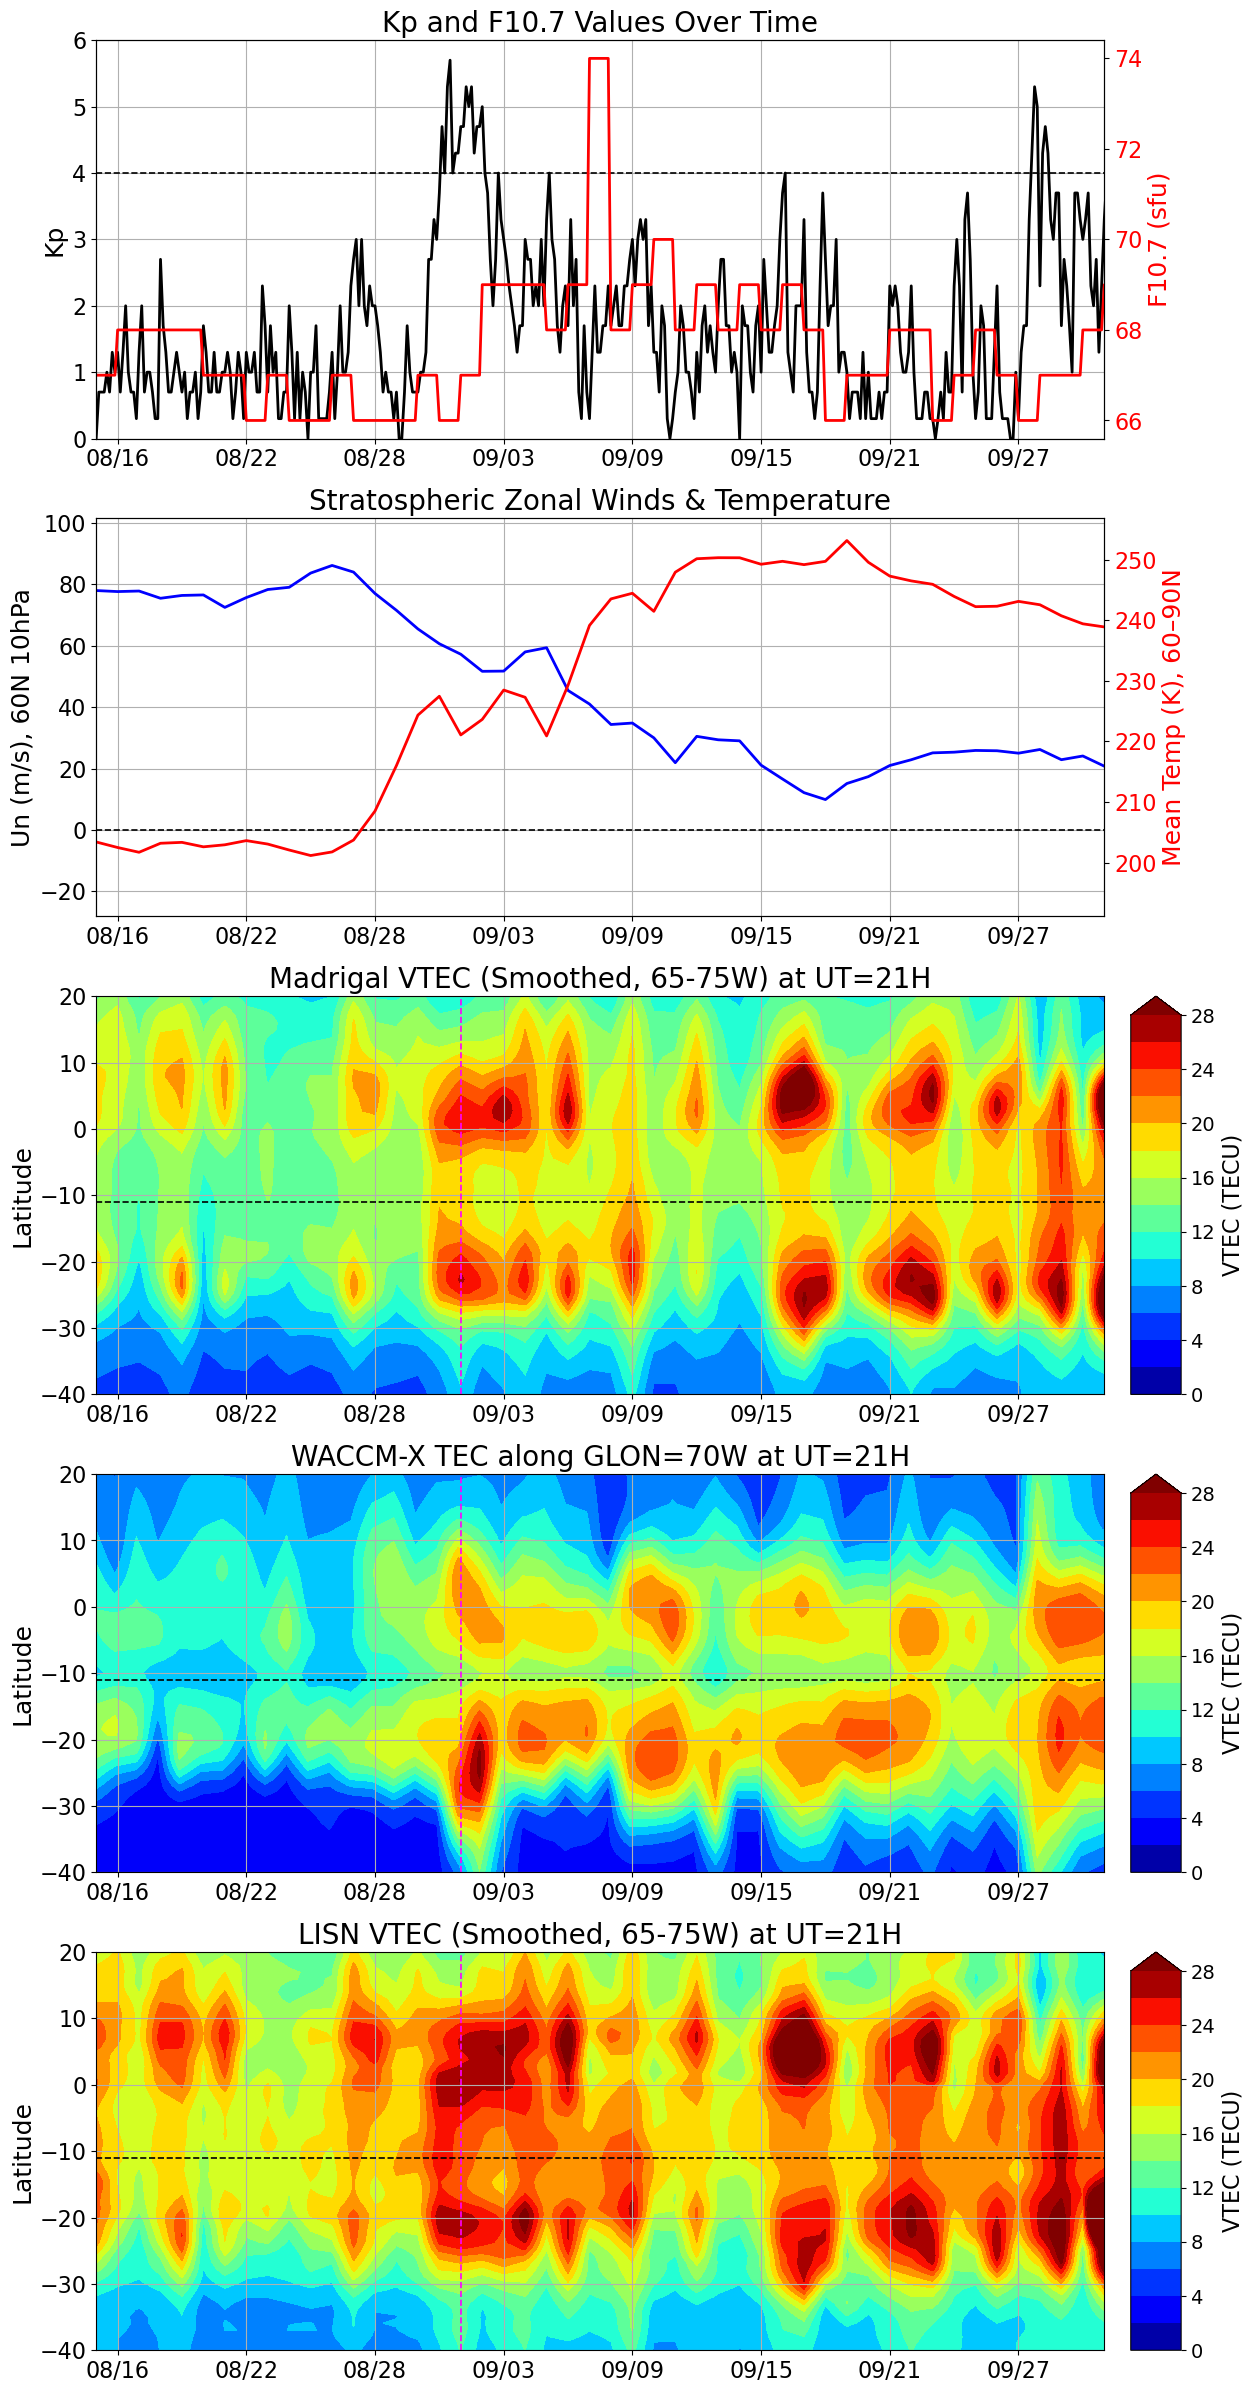

In [99]:
plot_all_rows(waccmx_ds, era5_u, era5_t, madrigal_processed, lisn_processed, date_range=(start_date, end_date))

In [44]:
print(lisn_processed)

([Timestamp('2019-07-29 00:00:00'), Timestamp('2019-07-30 00:00:00'), Timestamp('2019-07-31 00:00:00'), Timestamp('2019-08-01 00:00:00'), Timestamp('2019-08-02 00:00:00'), Timestamp('2019-08-03 00:00:00'), Timestamp('2019-08-04 00:00:00'), Timestamp('2019-08-05 00:00:00'), Timestamp('2019-08-06 00:00:00'), Timestamp('2019-08-07 00:00:00'), Timestamp('2019-08-08 00:00:00'), Timestamp('2019-08-09 00:00:00'), Timestamp('2019-08-10 00:00:00'), Timestamp('2019-08-11 00:00:00'), Timestamp('2019-08-12 00:00:00'), Timestamp('2019-08-13 00:00:00'), Timestamp('2019-08-14 00:00:00'), Timestamp('2019-08-15 00:00:00'), Timestamp('2019-08-16 00:00:00'), Timestamp('2019-08-17 00:00:00'), Timestamp('2019-08-18 00:00:00'), Timestamp('2019-08-19 00:00:00'), Timestamp('2019-08-20 00:00:00'), Timestamp('2019-08-21 00:00:00'), Timestamp('2019-08-22 00:00:00'), Timestamp('2019-08-23 00:00:00'), Timestamp('2019-08-24 00:00:00'), Timestamp('2019-08-25 00:00:00'), Timestamp('2019-08-26 00:00:00'), Timestamp('2